In [13]:
# Importing Libraries

In [14]:
import pandas as pd

In [15]:
import numpy as np

In [16]:
import matplotlib.pyplot as plt

In [17]:
import seaborn as sns

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
from sklearn.cluster import KMeans

In [20]:
# Loading Dataset

In [21]:
df=pd.read_csv("/content/drive/MyDrive/ecommerce_customers.csv")

In [22]:
# Inspecting  Dataset

In [23]:
df.head()

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_order_value,total_purchases,browsing_time_minutes,product_category_preference,...,cross_category_purchases,repeat_purchase_rate,avg_session_duration,pages_per_session,geographic_region,preferred_shipping,support_interactions,product_reviews_count,social_shares,coupon_redemptions
0,1,58,Male,16639,93,16,92.35,16,157,Clothing,...,3,0.76,1008,3,South,Same Day,1,8,4,1
1,2,66,Female,21698,72,18,87.90,18,184,Home & Garden,...,1,0.93,1055,6,North,Same Day,1,14,5,2
2,3,28,Female,38283,76,16,106.05,16,227,Clothing,...,3,0.84,397,13,West,Same Day,2,14,1,2
3,4,26,Male,32219,93,18,111.93,18,191,Beauty,...,1,0.76,876,14,North,Overnight,2,10,0,2
4,5,45,Male,44735,70,16,114.16,16,237,Home & Garden,...,1,0.85,267,14,West,Standard,2,4,4,3


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  100 non-null    int64  
 1   age                          100 non-null    int64  
 2   gender                       100 non-null    object 
 3   annual_income                100 non-null    int64  
 4   spending_score               100 non-null    int64  
 5   purchase_frequency           100 non-null    int64  
 6   avg_order_value              100 non-null    float64
 7   total_purchases              100 non-null    int64  
 8   browsing_time_minutes        100 non-null    int64  
 9   product_category_preference  100 non-null    object 
 10  device_type                  100 non-null    object 
 11  last_purchase_days           100 non-null    int64  
 12  segment                      100 non-null    object 
 13  customer_lifetime_val

In [25]:
df.shape

(100, 40)

In [26]:
df.columns

Index(['customer_id', 'age', 'gender', 'annual_income', 'spending_score',
       'purchase_frequency', 'avg_order_value', 'total_purchases',
       'browsing_time_minutes', 'product_category_preference', 'device_type',
       'last_purchase_days', 'segment', 'customer_lifetime_value',
       'return_rate', 'payment_method', 'newsletter_subscribed',
       'social_media_engagement', 'avg_review_rating', 'cart_abandonment_rate',
       'discount_usage_pct', 'referral_source', 'customer_satisfaction_score',
       'preferred_shopping_hour', 'mobile_app_user', 'wishlist_items',
       'customer_since_months', 'loyalty_tier', 'email_open_rate',
       'click_through_rate', 'cross_category_purchases',
       'repeat_purchase_rate', 'avg_session_duration', 'pages_per_session',
       'geographic_region', 'preferred_shipping', 'support_interactions',
       'product_reviews_count', 'social_shares', 'coupon_redemptions'],
      dtype='object')

In [27]:
df.describe()

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_order_value,total_purchases,browsing_time_minutes,last_purchase_days,customer_lifetime_value,...,email_open_rate,click_through_rate,cross_category_purchases,repeat_purchase_rate,avg_session_duration,pages_per_session,support_interactions,product_reviews_count,social_shares,coupon_redemptions
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.00000,100.000000
mean,50.500000,41.730000,31490.330000,50.500000,10.040000,183.646800,10.040000,107.410000,25.560000,2040.25200,...,0.235500,0.079600,1.470000,0.639500,662.830000,8.610000,1.580000,4.75000,4.05000,2.630000
std,29.011492,15.618466,10169.220141,31.976159,5.697634,98.881658,5.697634,74.109133,25.238787,1535.19896,...,0.176569,0.064931,1.029416,0.217439,307.888149,3.760225,1.248676,4.31201,4.01355,2.195749
min,1.000000,18.000000,15912.000000,3.000000,1.000000,85.420000,1.000000,5.000000,1.000000,59.76000,...,0.000000,0.000000,0.000000,0.210000,187.000000,3.000000,0.000000,0.00000,0.00000,0.000000
25%,25.750000,28.000000,22517.250000,17.750000,5.000000,105.162500,5.000000,42.000000,3.750000,723.69500,...,0.097500,0.030000,1.000000,0.447500,385.000000,5.000000,1.000000,1.00000,1.75000,1.000000
50%,50.500000,39.500000,30784.500000,43.500000,10.000000,160.745000,10.000000,87.000000,18.000000,1640.23000,...,0.180000,0.060000,1.000000,0.685000,637.000000,8.500000,2.000000,4.00000,3.00000,2.000000
75%,75.250000,54.250000,40469.250000,83.250000,15.000000,222.787500,15.000000,177.250000,41.000000,3191.90500,...,0.350000,0.122500,2.000000,0.830000,945.500000,12.000000,2.000000,6.25000,5.00000,3.000000
max,100.000000,70.000000,49962.000000,100.000000,20.000000,447.960000,20.000000,240.000000,84.000000,5820.26000,...,0.650000,0.290000,4.000000,0.950000,1198.000000,15.000000,5.000000,15.00000,16.00000,8.000000


In [28]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
annual_income,0
spending_score,0
purchase_frequency,0
avg_order_value,0
total_purchases,0
browsing_time_minutes,0
product_category_preference,0


In [29]:
# Descriptive Statistics

In [30]:
# Average Purchase Value
print("Average Purchase Value:",df["avg_order_value"].mean())

Average Purchase Value: 183.6468


In [31]:
# Purchase Frequency
print("Average Purchase Frequency:",df["purchase_frequency"].mean())

Average Purchase Frequency: 10.04


In [32]:
# Customer Lifetime Value
print("Average CLV:",df["customer_lifetime_value"].mean())

Average CLV: 2040.2519999999997


In [33]:
# Selecting Features

In [34]:
features = df[['last_purchase_days',
               'purchase_frequency',
               'customer_lifetime_value']]

In [35]:
# Standardization

In [36]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [37]:
# Elbow Method

In [41]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i,
                  random_state=42)

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

In [42]:
# Plot

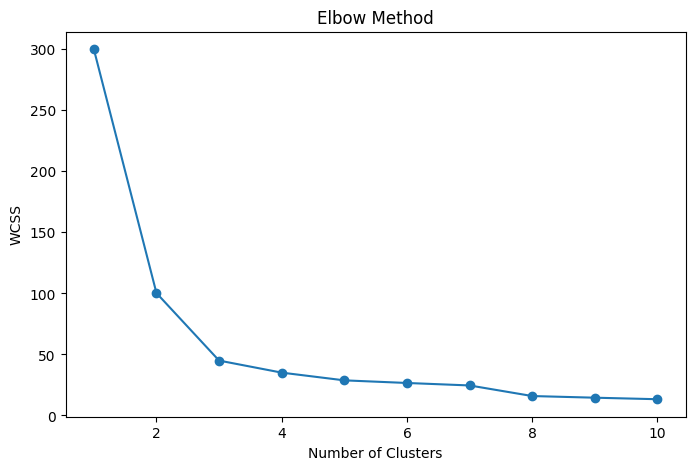

In [43]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [44]:
# Applying  KMeans

In [45]:
kmeans=KMeans(n_clusters=4,
              random_state=42)

df['Cluster']=kmeans.fit_predict(scaled_features)

In [46]:
# Scatter Plot 1

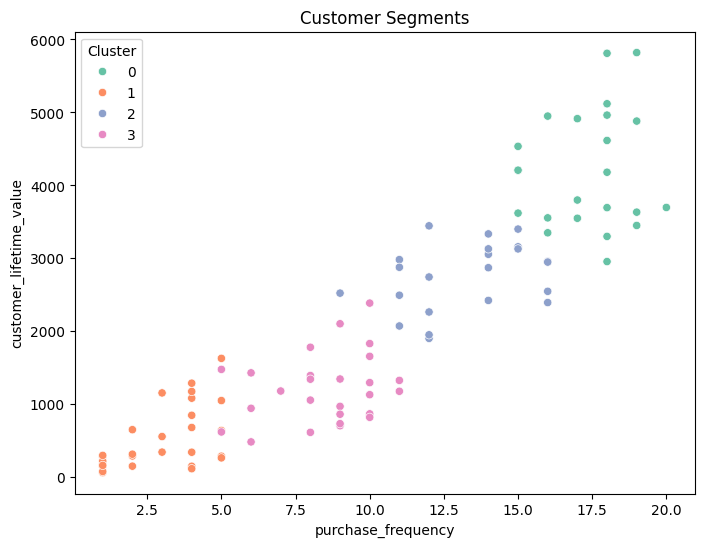

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="purchase_frequency",
    y="customer_lifetime_value",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [48]:
# Scatter Plot 2

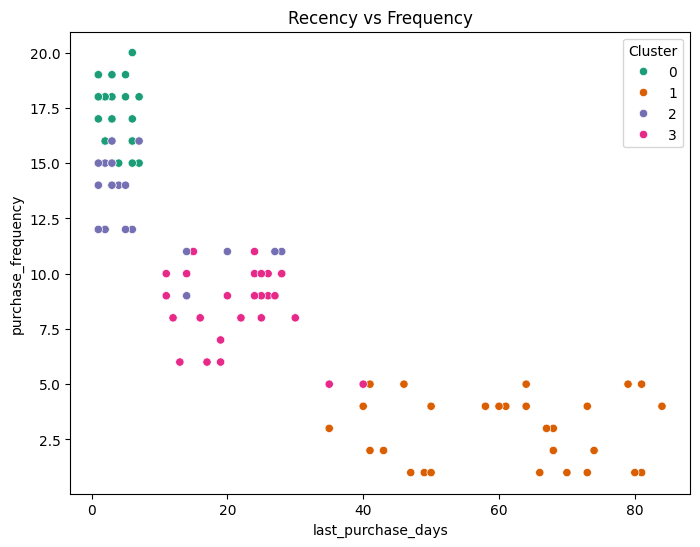

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="last_purchase_days",
    y="purchase_frequency",
    hue="Cluster",
    palette="Dark2"
)

plt.title("Recency vs Frequency")

plt.show()

In [50]:
# Cluster Profiling

In [51]:
cluster_profile=df.groupby("Cluster")[[
    "last_purchase_days",
    "purchase_frequency",
    "customer_lifetime_value"
]].mean()

cluster_profile

,last_purchase_days,purchase_frequency,customer_lifetime_value
Cluster,,,
0,3.478261,17.347826,4208.066087
1,61.178571,2.928571,512.785000
2,7.227273,13.272727,2753.077727
3,22.370370,8.555556,1196.814444


In [52]:
# Bar Chart

/tmp/ipykernel_1540/1861885731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Cluster",


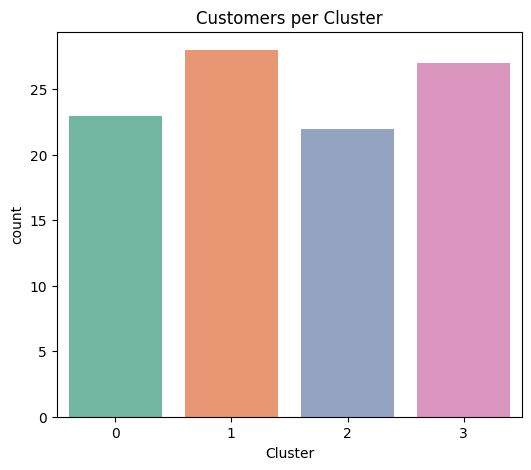

In [53]:
plt.figure(figsize=(6,5))

sns.countplot(x="Cluster",
              data=df,
              palette="Set2")

plt.title("Customers per Cluster")

plt.show()

In [54]:
# Business Insights

In [55]:
 # Cluster 0
# High Lifetime Value
# Frequent Purchases
# Loyal Customers

# Marketing Action
# Offer VIP membership and exclusive discounts.

In [57]:
# Cluster 1
# Low Purchase Frequency
# Low Spending

# Marketing Action
# Send promotional emails and discount coupons.

In [58]:
# Cluster 2
# Recent Customers
# Moderate Spending

# Marketing Action
# Recommend products based on browsing history.

In [59]:
# Cluster 3
# High Recency (inactive)
# Previously good customers

# Marketing Action
# Win-back campaigns with special offers.

In [60]:
# Conclusion

In [62]:
# K-Means clustering successfully segmented customers into four groups based on purchasing behavior.
 # High-value customers should be rewarded with loyalty programs, while inactive customers can be re-engaged using personalized offers.
 # This segmentation helps improve customer retention and targeted marketing strategies.